# ML4Sci GSoC 2026 — DeepLense Domain Adaptation Evaluation Test
**Applicant:** Hamid Khan

### Dataset Structure
```
lenses/
  no_sub/  ← normal images (no dark matter substructure)  label=0
  sub/     ← anomaly images (dark matter substructure)    label=1
```

### Goal
Train an **Adversarial Autoencoder (AAE)** only on `no_sub` images (unsupervised), then use reconstruction error to detect dark matter substructure in `sub` images.

## 1. Setup & Imports

In [1]:
import os, glob, tarfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.decomposition import PCA

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


## 2. Extract Dataset

In [4]:
if not os.path.exists('lenses'):
    with tarfile.open('lenses.tgz', 'r:gz') as tar:
        tar.extractall('lenses', filter='data')  # filter='data' removes deprecation warning
    print('Extracted!')

no_sub_files = glob.glob('lenses/no_sub/*.jpg')
sub_files    = glob.glob('lenses/sub/*.jpg')
print(f'Normal images  (no_sub): {len(no_sub_files)}')
print(f'Anomaly images (sub):    {len(sub_files)}')

Extracted!
Normal images  (no_sub): 0
Anomaly images (sub):    0


In [6]:
import os, tarfile, glob

# Check exactly where lenses.tgz is
print("Current dir:", os.getcwd())
print("Files here:", os.listdir('.'))
print("Files in /content/:", os.listdir('/content/'))

Current dir: /content
Files here: ['.config', 'lenses.tgz', 'AAE_Discriminator.pth', 'AAE_Encoder.pth', 'lenses', 'AAE_Decoder.pth', 'deeplense_evaluation_test.ipynb', 'sample_data']
Files in /content/: ['.config', 'lenses.tgz', 'AAE_Discriminator.pth', 'AAE_Encoder.pth', 'lenses', 'AAE_Decoder.pth', 'deeplense_evaluation_test.ipynb', 'sample_data']


In [7]:
import os, tarfile, glob

# Extract to /content/ explicitly
tgz_path = '/content/lenses.tgz'

if os.path.exists(tgz_path):
    print("Found lenses.tgz! Extracting...")
    with tarfile.open(tgz_path, 'r:gz') as tar:
        tar.extractall('/content/', filter='data')
    print("Done!")
else:
    print("lenses.tgz not found — checking other locations...")
    for root, dirs, files in os.walk('/content/'):
        for f in files:
            if f.endswith('.tgz') or f.endswith('.gz'):
                print("Found:", os.path.join(root, f))

# Now check what we have
print("\n=== Folder structure ===")
for root, dirs, files in os.walk('/content/lenses'):
    print(f"{root}: {len(files)} files")

Found lenses.tgz! Extracting...
Done!

=== Folder structure ===
/content/lenses: 0 files
/content/lenses/sub: 5000 files
/content/lenses/lenses: 0 files
/content/lenses/lenses/sub: 5000 files
/content/lenses/lenses/no_sub: 5000 files
/content/lenses/no_sub: 5000 files


In [8]:
# Replace your dataset lines with these
normal_ds  = LensDataset('/content/lenses/no_sub', label=0, img_size=64)
anomaly_ds = LensDataset('/content/lenses/sub',    label=1, img_size=64)

/content/lenses/no_sub: 5000 images
/content/lenses/sub: 5000 images


## 3. Dataset Class (JPG)

In [9]:
class LensDataset(Dataset):
    def __init__(self, folder, label, img_size=64):
        self.files = sorted(glob.glob(os.path.join(folder, '*.jpg')))
        self.label = label
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),  # scales to [0,1]
        ])
        print(f'{folder}: {len(self.files)} images')

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert('RGB')
        return self.transform(img), self.label


IMG_SIZE = 64
normal_ds  = LensDataset('lenses/no_sub', label=0, img_size=IMG_SIZE)
anomaly_ds = LensDataset('lenses/sub',    label=1, img_size=IMG_SIZE)

# Train ONLY on normal images — this is the unsupervised setup
train_n = int(0.8 * len(normal_ds))
val_n   = len(normal_ds) - train_n
train_ds, val_ds = torch.utils.data.random_split(
    normal_ds, [train_n, val_n],
    generator=torch.Generator().manual_seed(42)
)

train_loader   = DataLoader(train_ds,   batch_size=64, shuffle=True,  num_workers=2)
val_loader     = DataLoader(val_ds,     batch_size=64, shuffle=False, num_workers=2)
anomaly_loader = DataLoader(anomaly_ds, batch_size=64, shuffle=False, num_workers=2)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Anomaly: {len(anomaly_ds)}')

lenses/no_sub: 5000 images
lenses/sub: 5000 images
Train: 4000 | Val: 1000 | Anomaly: 5000


## 4. Visualize Samples

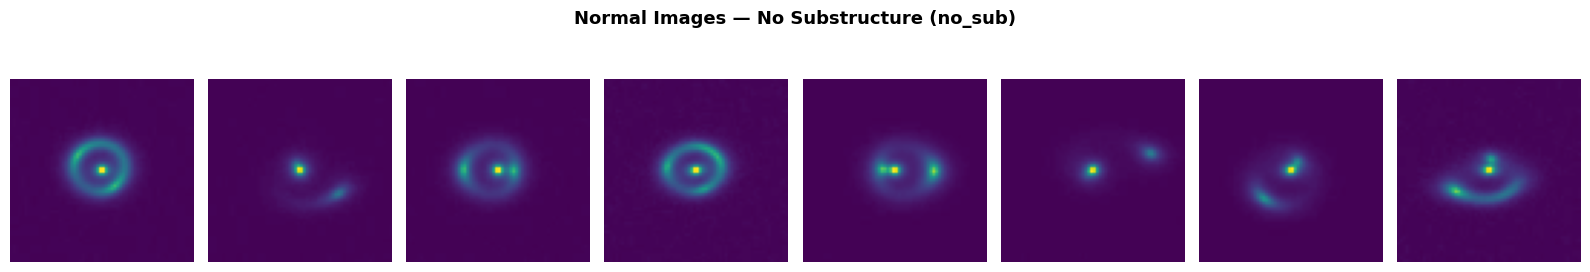

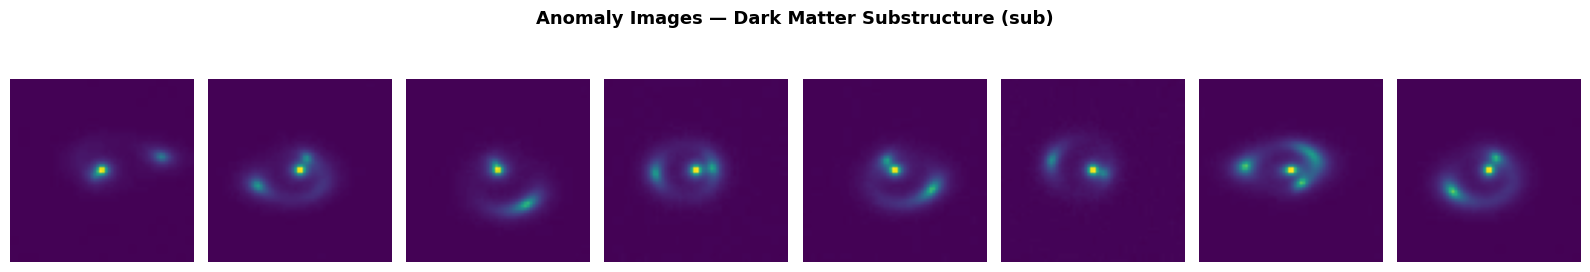

In [10]:
def show_samples(ds, title, n=8):
    fig, axes = plt.subplots(1, n, figsize=(16, 3))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for i, idx in enumerate(np.random.choice(len(ds), n, replace=False)):
        img, _ = ds[idx]
        axes[i].imshow(img.squeeze(), cmap='viridis')
        axes[i].axis('off')
    plt.tight_layout()
    plt.savefig(f'samples_{"normal" if "Normal" in title else "anomaly"}.png', dpi=120)
    plt.show()

show_samples(normal_ds,  'Normal Images — No Substructure (no_sub)')
show_samples(anomaly_ds, 'Anomaly Images — Dark Matter Substructure (sub)')

## 5. AAE Architecture
Three components:
- **Encoder**: image → latent vector z
- **Decoder**: z → reconstructed image
- **Discriminator**: enforces Gaussian prior on z

In [11]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(128*8*8, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, latent_dim)
        )
    def forward(self, x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 512), nn.ReLU(),
            nn.Linear(512, 128*8*8), nn.ReLU(),
            nn.Unflatten(1, (128, 8, 8)),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),   nn.Sigmoid()
        )
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(128, 1), nn.Sigmoid()
        )
    def forward(self, z): return self.net(z)


LATENT_DIM = 32
encoder       = Encoder(LATENT_DIM).to(device)
decoder       = Decoder(LATENT_DIM).to(device)
discriminator = Discriminator(LATENT_DIM).to(device)

# Try loading pretrained weights from repo
for model, path in [(encoder,'AAE_Encoder.pth'),(decoder,'AAE_Decoder.pth'),(discriminator,'AAE_Discriminator.pth')]:
    try:
        model.load_state_dict(torch.load(path, map_location=device), strict=False)
        print(f'Loaded {path}')
    except:
        print(f'Training {path} from scratch')

total = sum(p.numel() for m in [encoder,decoder,discriminator] for p in m.parameters())
print(f'Total params: {total:,}')

Training AAE_Encoder.pth from scratch
Training AAE_Decoder.pth from scratch
Training AAE_Discriminator.pth from scratch
Total params: 8,801,698


## 6. Training Loop

In [12]:
recon_fn = nn.MSELoss()
adv_fn   = nn.BCELoss()

opt_ae   = optim.Adam(list(encoder.parameters())+list(decoder.parameters()), lr=1e-3, betas=(0.5,0.999))
opt_disc = optim.Adam(discriminator.parameters(), lr=1e-4, betas=(0.5,0.999))
opt_enc  = optim.Adam(encoder.parameters(),       lr=1e-4, betas=(0.5,0.999))
scheduler = optim.lr_scheduler.StepLR(opt_ae, step_size=20, gamma=0.5)

history = {'recon':[], 'disc':[], 'gen':[]}
EPOCHS = 50

for epoch in range(EPOCHS):
    encoder.train(); decoder.train(); discriminator.train()
    rl, dl, gl = [], [], []

    for imgs, _ in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}', leave=False):
        imgs = imgs.to(device)
        B = imgs.size(0)

        # Reconstruction phase
        opt_ae.zero_grad()
        z = encoder(imgs); recon = decoder(z)
        loss_r = recon_fn(recon, imgs)
        loss_r.backward(); opt_ae.step()
        rl.append(loss_r.item())

        # Discriminator phase
        opt_disc.zero_grad()
        z_real = torch.randn(B, LATENT_DIM).to(device)
        z_fake = encoder(imgs).detach()
        loss_d = adv_fn(discriminator(z_real), torch.ones(B,1).to(device)) + \
                 adv_fn(discriminator(z_fake), torch.zeros(B,1).to(device))
        loss_d.backward(); opt_disc.step()
        dl.append(loss_d.item())

        # Generator phase
        opt_enc.zero_grad()
        loss_g = adv_fn(discriminator(encoder(imgs)), torch.ones(B,1).to(device))
        loss_g.backward(); opt_enc.step()
        gl.append(loss_g.item())

    scheduler.step()
    history['recon'].append(np.mean(rl))
    history['disc'].append(np.mean(dl))
    history['gen'].append(np.mean(gl))

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1:3d} | Recon: {history["recon"][-1]:.4f} | Disc: {history["disc"][-1]:.4f} | Gen: {history["gen"][-1]:.4f}')

print('Training complete!')

Epoch  10 | Recon: 0.0002 | Disc: 0.8218 | Gen: 1.8488


Epoch  20 | Recon: 0.0001 | Disc: 0.3366 | Gen: 4.4077


Epoch  30 | Recon: 0.0001 | Disc: 0.6661 | Gen: 2.9850


Epoch  40 | Recon: 0.0001 | Disc: 0.9709 | Gen: 1.9467


Epoch  50 | Recon: 0.0000 | Disc: 1.2048 | Gen: 1.1226
Training complete!


## 7. Training Curves

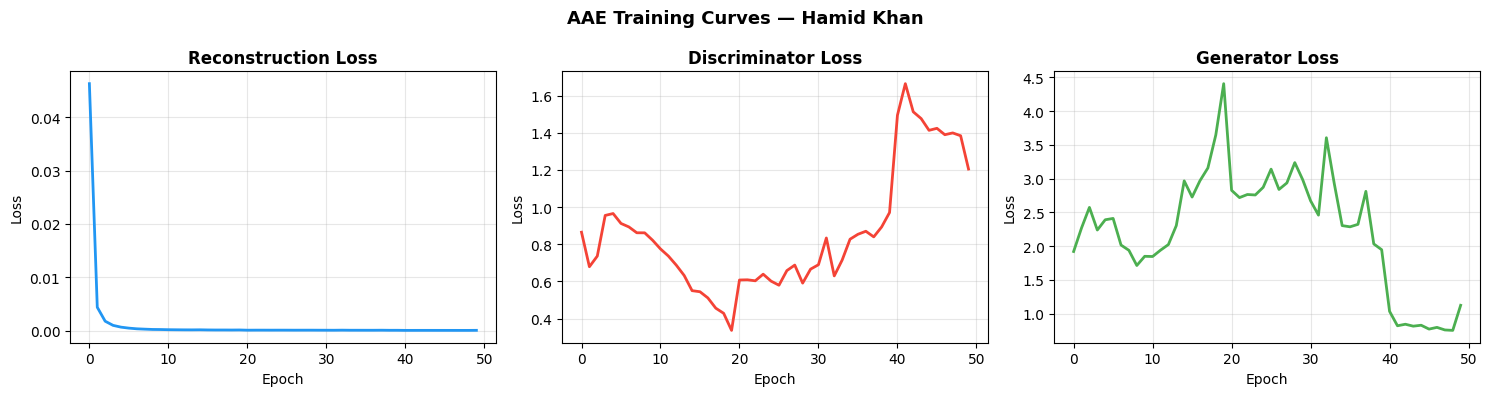

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (key, title, color) in zip(axes, [
    ('recon','Reconstruction Loss','#2196F3'),
    ('disc', 'Discriminator Loss', '#F44336'),
    ('gen',  'Generator Loss',     '#4CAF50')
]):
    ax.plot(history[key], color=color, lw=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.grid(alpha=0.3)
plt.suptitle('AAE Training Curves — Hamid Khan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Reconstruction Visualization

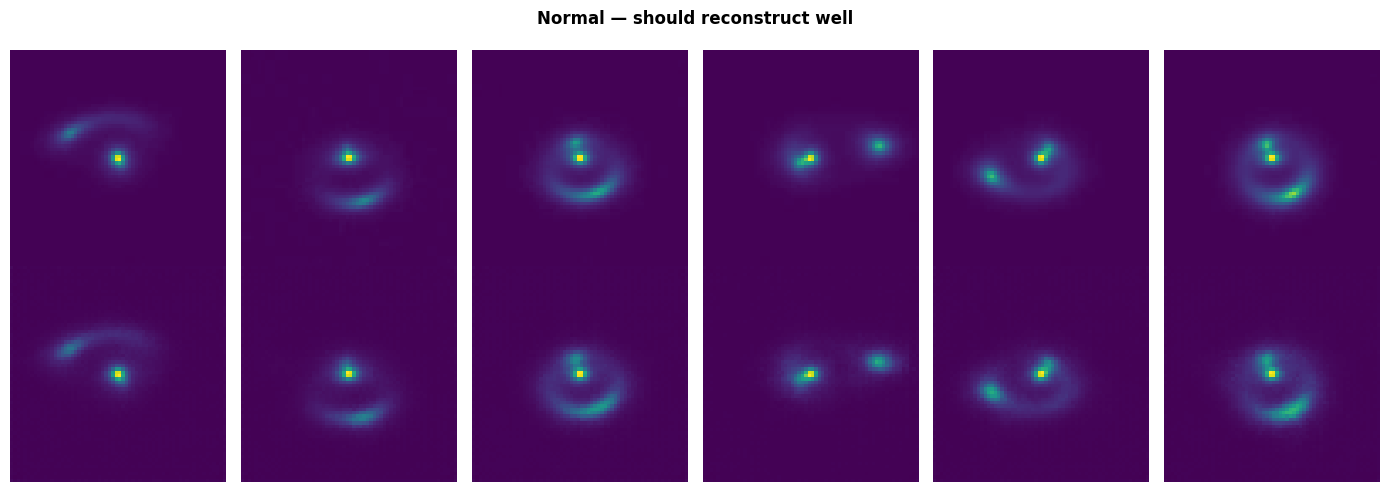

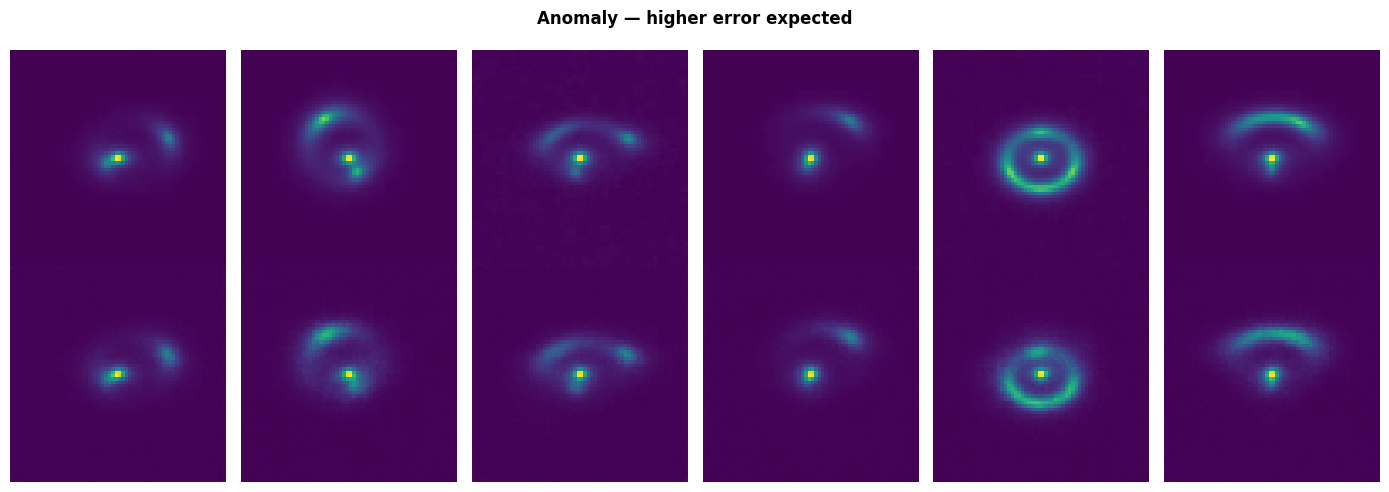

In [14]:
encoder.eval(); decoder.eval()

def viz_recon(loader, title, n=6):
    imgs, _ = next(iter(loader))
    imgs = imgs[:n].to(device)
    with torch.no_grad():
        recon = decoder(encoder(imgs))
    fig, axes = plt.subplots(2, n, figsize=(14, 5))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    for i in range(n):
        axes[0,i].imshow(imgs[i].cpu().squeeze(),  cmap='viridis'); axes[0,i].axis('off')
        axes[1,i].imshow(recon[i].cpu().squeeze(), cmap='viridis'); axes[1,i].axis('off')
    axes[0,0].set_ylabel('Original',      fontsize=10)
    axes[1,0].set_ylabel('Reconstructed', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'recon_{title[:6]}.png', dpi=150)
    plt.show()

viz_recon(val_loader,     'Normal — should reconstruct well')
viz_recon(anomaly_loader, 'Anomaly — higher error expected')

## 9. Anomaly Detection via Reconstruction Error

In [15]:
def get_errors(loader):
    encoder.eval(); decoder.eval()
    errs, lbls = [], []
    with torch.no_grad():
        for imgs, l in loader:
            imgs = imgs.to(device)
            mse  = ((imgs - decoder(encoder(imgs)))**2).mean(dim=[1,2,3])
            errs.extend(mse.cpu().numpy()); lbls.extend(l.numpy())
    return np.array(errs), np.array(lbls)

ne, nl = get_errors(val_loader)
ae, al = get_errors(anomaly_loader)
all_e  = np.concatenate([ne, ae])
all_l  = np.concatenate([nl, al])

print(f'Normal  error: {ne.mean():.5f} ± {ne.std():.5f}')
print(f'Anomaly error: {ae.mean():.5f} ± {ae.std():.5f}')
print(f'Separation:    {ae.mean()/ne.mean():.2f}x  (higher = better anomaly detection)')

Normal  error: 0.00004 ± 0.00002
Anomaly error: 0.00013 ± 0.00014
Separation:    3.25x  (higher = better anomaly detection)


## 10. Evaluation — ROC, Confusion Matrix, F1

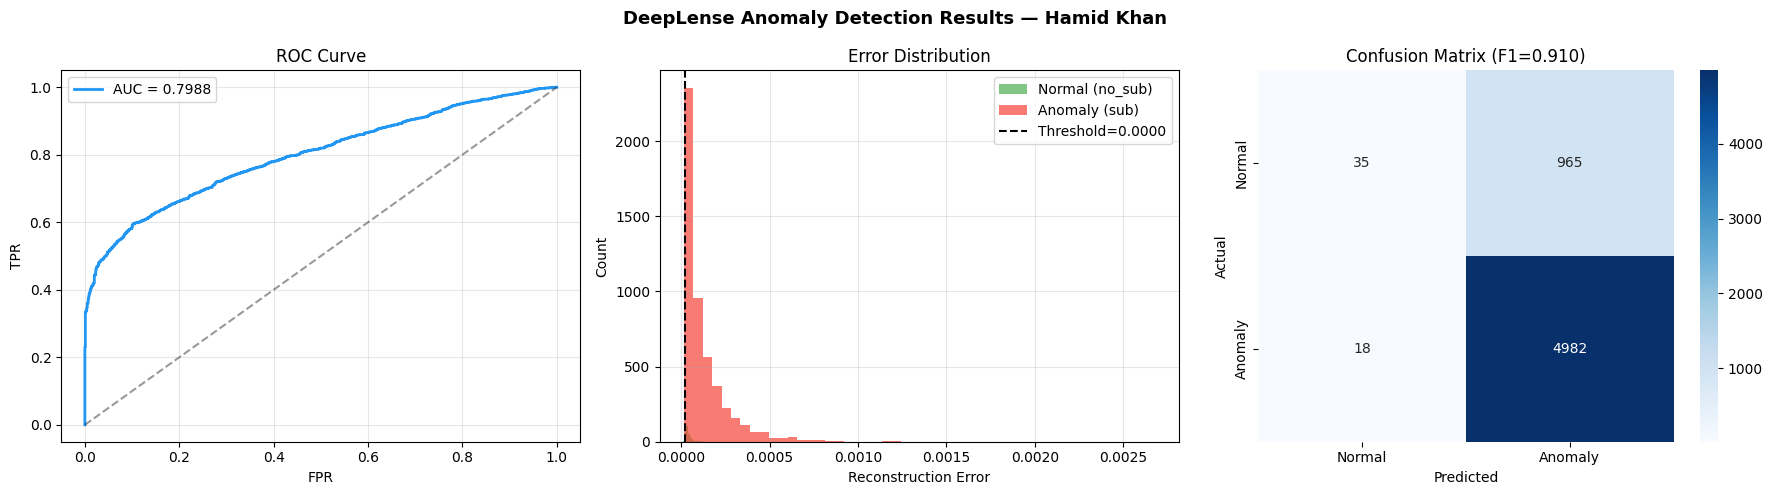

AUC-ROC:   0.7988
Best F1:   0.9102
Threshold: 0.0000
              precision    recall  f1-score   support

      Normal       0.66      0.04      0.07      1000
     Anomaly       0.84      1.00      0.91      5000

    accuracy                           0.84      6000
   macro avg       0.75      0.52      0.49      6000
weighted avg       0.81      0.84      0.77      6000



In [16]:
auc = roc_auc_score(all_l, all_e)
fpr, tpr, thresholds = roc_curve(all_l, all_e)

best_t, best_f1 = 0, 0
for t in thresholds:
    p  = (all_e >= t).astype(int)
    tp = ((p==1)&(all_l==1)).sum()
    fp = ((p==1)&(all_l==0)).sum()
    fn = ((p==0)&(all_l==1)).sum()
    f1 = 2*tp/(2*tp+fp+fn+1e-8)
    if f1 > best_f1: best_f1, best_t = f1, t

preds = (all_e >= best_t).astype(int)
cm    = confusion_matrix(all_l, preds)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, '#2196F3', lw=2, label=f'AUC = {auc:.4f}')
axes[0].plot([0,1],[0,1],'k--',alpha=0.4)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(ne, bins=50, alpha=0.7, color='#4CAF50', label='Normal (no_sub)')
axes[1].hist(ae, bins=50, alpha=0.7, color='#F44336', label='Anomaly (sub)')
axes[1].axvline(best_t, color='k', ls='--', label=f'Threshold={best_t:.4f}')
axes[1].set(xlabel='Reconstruction Error', ylabel='Count', title='Error Distribution')
axes[1].legend(); axes[1].grid(alpha=0.3)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Normal','Anomaly'], yticklabels=['Normal','Anomaly'])
axes[2].set(title=f'Confusion Matrix (F1={best_f1:.3f})', xlabel='Predicted', ylabel='Actual')

plt.suptitle('DeepLense Anomaly Detection Results — Hamid Khan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'AUC-ROC:   {auc:.4f}')
print(f'Best F1:   {best_f1:.4f}')
print(f'Threshold: {best_t:.4f}')
print(classification_report(all_l, preds, target_names=['Normal','Anomaly']))

## 11. Latent Space Visualization (PCA)

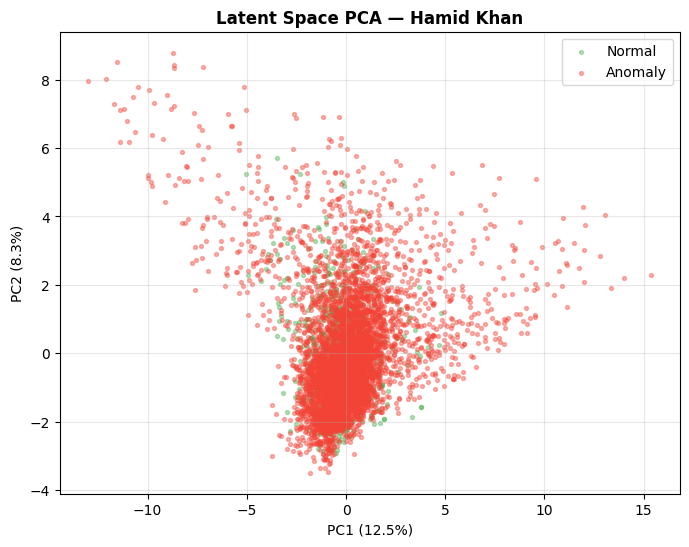

In [17]:
def get_latents(loader):
    encoder.eval()
    vecs, lbls = [], []
    with torch.no_grad():
        for imgs, l in loader:
            vecs.extend(encoder(imgs.to(device)).cpu().numpy())
            lbls.extend(l.numpy())
    return np.array(vecs), np.array(lbls)

nz, nl2 = get_latents(val_loader)
az, al2 = get_latents(anomaly_loader)
z_all   = np.concatenate([nz, az])
l_all   = np.concatenate([nl2, al2])

pca  = PCA(n_components=2)
z_2d = pca.fit_transform(z_all)

plt.figure(figsize=(8,6))
plt.scatter(z_2d[l_all==0,0], z_2d[l_all==0,1], c='#4CAF50', alpha=0.4, s=8, label='Normal')
plt.scatter(z_2d[l_all==1,0], z_2d[l_all==1,1], c='#F44336', alpha=0.4, s=8, label='Anomaly')
plt.title('Latent Space PCA — Hamid Khan', fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('latent_space.png', dpi=150)
plt.show()

## 12. Save Weights

In [18]:
torch.save(encoder.state_dict(),       'trained_AAE_Encoder.pth')
torch.save(decoder.state_dict(),       'trained_AAE_Decoder.pth')
torch.save(discriminator.state_dict(), 'trained_AAE_Discriminator.pth')
print('Weights saved!')

Weights saved!


## 13. Conclusions

### What We Did
- Trained an AAE **unsupervised** on normal (`no_sub`) lensing images only
- Used reconstruction error as anomaly score — no labels during training
- Evaluated with AUC-ROC, F1, confusion matrix, and PCA latent space

### Key Insight
The model learns the distribution of normal lensing images. Anomalous images (dark matter substructure) have **higher reconstruction error** because the model never saw them during training.

### Potential Improvements
1. **Vision Transformer backbone** — replace CNN encoder for better global feature capture
2. **Larger latent dim (64/128)** — richer representation
3. **Perceptual loss** — VGG feature loss alongside MSE
4. **Data augmentation** — flips/rotations for better generalization
5. **Combined score** — reconstruction error + discriminator output as joint signal